In [1]:
#1. OBSERVAMOS LAS DIMENSIONES DE LOS DATOS
import h5py as h5
import numpy as np
import time
import pandas as pd
import os
import json
# 1. Configuración de la ruta
ruta_maestra = r"/home/antonio/Proyecto_Fluidos_AI/datos_procesados/process_data.h5"

ruta_carpeta_guardar= r"/home/antonio/Proyecto_Fluidos_AI/datos_procesados/runtransformerpro1"
# Crear la carpeta si no existe
os.makedirs(ruta_carpeta_guardar, exist_ok=True)

with h5.File(ruta_maestra, 'r') as f:
    # Leemos las dimensiones de las tres componentes
    grupo = f['data_analisis']
    u_shape = grupo['u_fluc'].shape
    v_shape = grupo['v_fluc'].shape
    w_shape = grupo['w_fluc'].shape

# Verificación de seguridad: las 3 matrices deben ser idénticas en tamaño
assert u_shape == v_shape == w_shape, "¡Error crítico! Las dimensiones de U, V y W no coinciden."

num_tiempos = u_shape[0]
dim_y = u_shape[1] #number of lines of probes
dim_z = u_shape[2]
total_puntos_espaciales = dim_y * dim_z

print("--- ESTADÍSTICAS DEL DATASET MULTICANAL ---")
print(f"Total de instantes de tiempo: {num_tiempos}")
print(f"Malla espacial: {dim_y} x {dim_z} = {total_puntos_espaciales} puntos")
print(f"Canales de velocidad: 3 (U, V, W)")
print(f"Total de datos numéricos a procesar: {num_tiempos * total_puntos_espaciales * 3:,}")

# 2. CÁLCULO DE DIVISIONES (Splits temporales)
# Primero separamos el 20% para el examen final (test/resultados)
indice_test = int(num_tiempos * 0.8)

# Del 80% restante, separamos otro 20% para validación (0.8 * 0.8 = 0.64)
indice_val = int(indice_test * 0.8)

salto = 50

print("\n--- REPARTO DEL TIEMPO ---")
print(f"1. Entrenamiento (64%): Pasos 0 al {indice_val}")
print(f"2. Validación    (16%): Pasos {indice_val} al {indice_test}")
print(f"3. Resultados    (20%): Pasos {indice_test} al {num_tiempos}")

--- ESTADÍSTICAS DEL DATASET MULTICANAL ---
Total de instantes de tiempo: 106000
Malla espacial: 7 x 288 = 2016 puntos
Canales de velocidad: 3 (U, V, W)
Total de datos numéricos a procesar: 641,088,000

--- REPARTO DEL TIEMPO ---
1. Entrenamiento (64%): Pasos 0 al 67840
2. Validación    (16%): Pasos 67840 al 84800
3. Resultados    (20%): Pasos 84800 al 106000


In [2]:
#2. PREPARACIÓN DE LOS DATOS PARA EL MODELO
import torch
from torch.utils.data import TensorDataset, DataLoader 
import os
import gc  # <--- Importamos el recolector de basura

def obtener_o_crear_datasets(ruta_maestra, train_dataset_pt_tf, val_dataset_pt_tf, stats_pt_tf, linea_idy):
    """
    Comprueba si existen los archivos procesados. 
    Si existen, los carga. Si no, ejecuta la lógica de 5760 columnas y los guarda.
    """
    
    # 1. Comprobar si AMBOS archivos ya existen en el disco
    if os.path.exists(train_dataset_pt_tf) and os.path.exists(val_dataset_pt_tf) and os.path.exists(stats_pt_tf):
        print(f"📦 Archivos detectados. Cargando datasets desde {train_dataset_pt_tf}...")
        train_ds = torch.load(train_dataset_pt_tf,weights_only=False)
        val_ds = torch.load(val_dataset_pt_tf,weights_only=False)
        stats = torch.load(stats_pt_tf, weights_only=False)
        return train_ds, val_ds, stats


    else:

        with h5.File(ruta_maestra, 'r') as f:
            # 1. Suponiendo que 'datos' es tu matriz original de forma (106000, 7, 288)
            matriz_base = f['data_analisis']['u_fluc'][:, linea_idy, :]  # Forma: (106000, 288)

            # 2. Definimos las dimensiones y el tamaño de los paquetes
            chunk_size = 16500  # Número de filas por paquete (chunk)
            num_chunks = len(matriz_base) // chunk_size  # 106000 // 5050 = 20

            # Recortamos la matriz para que el tamaño sea múltiplo exacto
            matriz_recortada = matriz_base[:num_chunks * chunk_size, :]

            # 3. Transformación de las dimensiones
           
            trozos = []
            for i in range(num_chunks):
                inicio = i * chunk_size
                fin = (i + 1) * chunk_size
                pedazo = matriz_recortada[inicio:fin, :]
                trozos.append(pedazo)

            # 3. Los "pegamos" de lado (horizontalmente)
            # matriz_final pasará a ser (5050, 288 * 20) = (5050, 5760)
            matriz_final_raw = np.hstack(trozos)

            print("Forma de la matriz final:", matriz_final_raw.shape) # Imprimirá (5050, 5760)

        # 5. DIVISIÓN 80/20 DE LAS COLUMNAS (5760)
        # ==========================================
        total_columnas = matriz_final_raw.shape[1] # 5760
        split_idx = int(total_columnas * 0.8) # 4608

        # 1. Creamos una lista de índices y la barajamos aleatoriamente
        # Usamos una semilla (seed) para que la aleatoriedad sea igual siempre que ejecutes el código
        np.random.seed(42) 
        indices_barajados = np.random.permutation(total_columnas)


        # 2. Separamos esos índices en los grupos de entrenamiento y validación
        train_indices = indices_barajados[:split_idx] # Los primeros 4608 números aleatorios
        val_indices = indices_barajados[split_idx:]   # Los 1152 restantes

        # Extraemos TODA la serie temporal (5050 pasos) pero separada por puntos espaciales
        matriz_train_raw = matriz_final_raw[:, train_indices] # Forma: (5050, 4608)
        matriz_val_raw = matriz_final_raw[:, val_indices]     # Forma: (5050, 1152)


                
        #Normalizamos los datos usando la media y desviación de X_data_raw (¡MUY IMPORTANTE!)
        media_X = np.mean(matriz_train_raw)
        std_X = np.std(matriz_train_raw)

        #Guardamos las estadísticas para usarlas en la normalización de los datos de validación y test
        stats = {
            'media': media_X,
            'std': std_X
        }

        matriz_train = np.float32((matriz_train_raw - media_X) / std_X)
        matriz_val = np.float32((matriz_val_raw - media_X) / std_X)

        # TRUCO 2: Borramos las variables gigantes que ya no usamos y vaciamos RAM
        del matriz_final_raw, matriz_train_raw, matriz_val_raw, trozos, matriz_recortada
        gc.collect()

        # ==========================================
        # 6. CREACIÓN DE VENTANAS DESLIZANTES
        # ==========================================
        seq_x = 3000  # Historia pasada (Input Transformer)
        seq_y = 50   # Futuro a predecir (Output Transformer)
        salto = 20   # Cuántos pasos temporales saltamos por ventana (ahorra RAM)

        def crear_ventanas(matriz, lookback, predict, stride):
            X_lista, y_lista = [], []
            num_tiempos = matriz.shape[0]
            
            # Deslizamos la ventana por el eje del tiempo
            for i in range(0, num_tiempos - lookback - predict + 1, stride):
                # Extraemos los bloques de tiempo
                bloque_x = matriz[i : i + lookback, :]       # Forma: (500, columnas)
                bloque_y = matriz[i + lookback : i + lookback + predict, :] # Forma: (50, columnas)
                
                # Transponemos (.T) para que las columnas (puntos espaciales) sean los ejemplos (filas)
                # Al transponer: bloque_x pasa de (500, col) a (col, 500)
                X_lista.append(bloque_x.T)
                y_lista.append(bloque_y.T)
            
            # Apilamos verticalmente todos los fragmentos generados
            return np.vstack(X_lista), np.vstack(y_lista)
        


        print("\nGenerando ventanas deslizantes (esto puede tardar unos segundos)...")
        X_train_np_tf, y_train_np_tf = crear_ventanas(matriz_train, seq_x, seq_y, salto)
        X_val_np_tf, y_val_np_tf = crear_ventanas(matriz_val, seq_x, seq_y, salto)

        print(f"Total ejemplos Entrenamiento: {X_train_np_tf.shape[0]}")
        print(f"Total ejemplos Validación: {X_val_np_tf.shape[0]}")

        # ==========================================
        # 7. CONVERSIÓN A TENSORES
        # ==========================================

        train_features = torch.from_numpy(X_train_np_tf).unsqueeze(-1)
        val_features = torch.from_numpy(X_val_np_tf).unsqueeze(-1)


        train_labels = torch.from_numpy(y_train_np_tf).unsqueeze(-1)
        val_labels = torch.from_numpy(y_val_np_tf).unsqueeze(-1)


        del X_train_np_tf, y_train_np_tf, X_val_np_tf, y_val_np_tf
        gc.collect()


        #Organizamos las matrices en DataLoaders para entrenamiento y validación
        train_dataset = TensorDataset(train_features, train_labels)
        val_dataset = TensorDataset(val_features, val_labels)

        #Guardamos los datasets para usarlos en el entrenamiento de la red neuronal
        torch.save(train_dataset, train_dataset_pt_tf)
        torch.save(val_dataset, val_dataset_pt_tf)
        torch.save(stats, stats_pt_tf)

        return train_dataset, val_dataset, stats

# Seleccionamos la línea o matriz que nos interesa 
linea_idy=2

# --- MODO DE USO ---
# Define los nombres de tus archivos
f_train = 'train_dataset_tf_pro1.pt'
f_val = 'val_dataset_tf_pro1.pt'
f_stats = 'norm_stats_tf_pro1.pt'

# Llamas a la función
train_dataset, val_dataset, stats_norm = obtener_o_crear_datasets(ruta_maestra, f_train, f_val, f_stats, linea_idy)

train_loader= DataLoader(train_dataset, batch_size=1024, shuffle=True,drop_last=False, num_workers=4, pin_memory=True)
val_loader= DataLoader(val_dataset, batch_size=1024, shuffle=False,drop_last=False, num_workers=4, pin_memory=True)

📦 Archivos detectados. Cargando datasets desde train_dataset_tf_pro1.pt...


In [3]:
#3. DEFINIMOS NUESTRO MODELO TRANSFORMER

import torch
import torch.nn as nn
import math

class MultiHeadEasyAttention(nn.Module):
    def __init__(self, seq_len, input_dim, d_model, num_heads=4):
        super().__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # Tensor \alpha para múltiples cabezas: (h, p, p)
        self.alpha = nn.Parameter(torch.empty(num_heads, seq_len, seq_len))
        nn.init.xavier_uniform_(self.alpha)
        
        # Proyección compartida W_V para todas las cabezas
        self.W_v = nn.Linear(input_dim, d_model, bias=False)

    def forward(self, x):
        b, p, _ = x.size() # b=Batch, p=seq_len
        
        # 1. Proyectar valores: (Batch, seq_len, d_model)
        V = self.W_v(x)
        
        # 2. Separar en múltiples cabezas: (Batch, seq_len, num_heads, head_dim)
        V = V.view(b, p, self.num_heads, self.head_dim)
        # Transponer para emparejar con alpha: (Batch, num_heads, seq_len, head_dim)
        V = V.permute(0, 2, 1, 3)
        
        # 3. Multiplicar cada cabeza de \alpha con su bloque V correspondiente
        # 'hij' (alpha), 'bhjd' (V) -> 'bhid' (salida por cabeza)
        out = torch.einsum('hij,bhjd->bhid', self.alpha, V)
        
        # 4. Concatenar las cabezas de vuelta al tamaño d_model
        out = out.permute(0, 2, 1, 3).contiguous().view(b, p, -1)
        return out
    

class EasyTransformerBlock(nn.Module):
    # 🚨 NUEVO: DROPOUT 🚨 Se añade como parámetro (0.1 = 10% de neuronas apagadas)
    def __init__(self, seq_len, d_model=64, num_heads=4, dropout_rate=0.1):
        super().__init__()
        self.attention = MultiHeadEasyAttention(seq_len, d_model, d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        
        # 🚨 NUEVO: DROPOUT 🚨 Después de la atención
        self.dropout1 = nn.Dropout(dropout_rate)
        
        expansion_factor = 4
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_model * expansion_factor), 
            nn.ReLU(),
            # 🚨 NUEVO: DROPOUT 🚨 Dentro del bloque Feed Forward
            nn.Dropout(dropout_rate),
            nn.Linear(d_model * expansion_factor, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        
        # 🚨 NUEVO: DROPOUT 🚨 Después del Feed Forward
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Bloque 1: Atención + Dropout + Residual + Normalización
        attn_out = self.attention(x)
        attn_out = self.dropout1(attn_out) # 🚨 Aplicamos Dropout 1
        x = self.norm1(x + attn_out)
        
        # Bloque 2: Feed Forward + Dropout + Residual + Normalización
        ff_out = self.feed_forward(x)
        ff_out = self.dropout2(ff_out)     # 🚨 Aplicamos Dropout 2
        x = self.norm2(x + ff_out)
        return x

class EasyFluidPredictor(nn.Module):
    # 🚨 NUEVO: DROPOUT 🚨 Lo pasamos como parámetro general
    def __init__(self, seq_len=500, pred_len=50, input_dim=1, d_model=64, num_heads=4, dropout_rate=0.1):
        super().__init__()
        self.input_dim = input_dim
        
        # 1. Proyección de entrada y el bloque Transformer (le pasamos el dropout)
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # 🚨 NUEVO: DROPOUT 🚨 Aislamos la entrada antes de que entre al transformer
        self.input_dropout = nn.Dropout(dropout_rate)
        
        self.easy_transformer = EasyTransformerBlock(seq_len, d_model, num_heads, dropout_rate)
        
        # 2. Las capas temporales (Aquí no solemos poner dropout para no destruir la secuencia de salida)
        self.temporal_proj = nn.Linear(seq_len, pred_len)  
        self.final_proj = nn.Linear(d_model, input_dim)     

    def forward(self, x):
        # Entrada original: (Batch, 500, 1)
        
        x = self.input_proj(x)          # Forma: (Batch, 500, 64)
        x = self.input_dropout(x)       # 🚨 Aplicamos Dropout a la entrada
        x = self.easy_transformer(x)    # Forma: (Batch, 500, 64)
        
        # --- 🧠 LÓGICA TEMPORAL COMPLETADA ---
        
        # Pasamos de (Batch, Tiempo, Canales) a (Batch, Canales, Tiempo)
        x = x.permute(0, 2, 1)          # Forma: (Batch, 64, 500)
        
        # Transformamos los 500 instantes del pasado en los 50 del futuro de golpe
        x = self.temporal_proj(x)       # Forma: (Batch, 64, 50)
        
        # Devolvemos las dimensiones a su orden natural: (Batch, Tiempo_Futuro, Canales)
        x = x.permute(0, 2, 1)          # Forma: (Batch, 50, 64)
        
        # Proyectamos los 64 canales ocultos a tu variable física u (1 canal)
        out = self.final_proj(x)        # Forma final: (Batch, 50, 1)
        
        return out

In [36]:
#4. ENTRENAMOS NUESTRA RED NEURONAL
# ==========================================
# 1. CONFIGURACIÓN DEL HARDWARE
# ==========================================

# Detectar si hay Tarjeta Gráfica (GPU) disponible. Si no, usará la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")


# 🚨 AUTODETECCIÓN DE DIMENSIONES 🚨
# train_dataset[0] devuelve la primera tupla (X, Y)
ejemplo_x, ejemplo_y = train_dataset[0]

num_heads = 8  # Puedes ajustar este número según la capacidad de tu GPU y la complejidad que quieras

d_model = 128  # Dimensión interna del modelo (puedes ajustar este número para hacerlo más pequeño o más grande)

input_dim = ejemplo_x.shape[1]  # Cada punto espacial es un canal de entrada

pred_len = ejemplo_y.shape[0]  # Número de pasos futuros a predecir

seq_len = ejemplo_x.shape[0]  # Número de pasos pasados que el modelo usará para predecir

lr=0.0001  # Tasa de aprendizaje para el optimizador



modelo = EasyFluidPredictor(seq_len=seq_len, pred_len=pred_len, input_dim=input_dim, d_model=d_model, num_heads=num_heads)

# Movemos el modelo a la tarjeta gráfica (o lo dejamos en CPU)
modelo.to(device)


criterio = torch.nn.MSELoss()

# --- 🚀 NUEVO: CONFIGURACIÓN DE PÉRDIDA POR GRADIENTE ---
# 0.1 o 0.2 suele ser el "punto dulce" para empezar. 
# Si notas que la línea roja se vuelve demasiado caótica o "nerviosa", baja este valor a 0.05.
peso_gradiente = 0.1


optimizador = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)

# --- 🚀 NUEVO: SCHEDULER DE TASA DE APRENDIZAJE ---
# Si la validación (val_loss) no mejora durante 15 épocas, bajamos el learning rate a la mitad (0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, 
    mode='min', 
    factor=0.001, 
    patience=15, 
)


# Acelerador de hardware de PyTorch
scaler = torch.cuda.amp.GradScaler()



# ==========================================
# 2. PARÁMETROS DEL ENTRENAMIENTO
# ==========================================
epocas = 500  # Número de veces que la IA verá TODO el dataset completo
tek=time.time()


historial_train_loss = []
historial_val_loss = []
#Creamos para guadar el mejor modelo basado en la pérdida de validación
best_val_loss = float('inf')  # Empezamos con "infinito" para que cualquier pérdida sea menor
ruta_mejor_modelo = ruta_carpeta_guardar+'/mejor_modelo_ia_transformer_eas.pt'

print("\n🚀 ¡Iniciando el entrenamiento de la Red Neuronal!")
print("-" * 60)

# ==========================================
# 3. EL BUCLE PRINCIPAL
# ==========================================
for epoca in range(epocas):
    print(f"\n📊 Época {epoca+1}/{epocas}")
    tic = time.time()
    
    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()  # Ponemos el modelo en modo "aprender"
    train_loss_acumulada = 0.0

    
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        print(f"   Procesando lote {batch_idx+1}/{len(train_loader)}", end='\r')
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
       # a) Reiniciamos los gradientes
        optimizador.zero_grad()
        
        # --- 🚀 NUEVO: MODO TURBO (PRECISIÓN MIXTA) ---
        with torch.cuda.amp.autocast():
            # b) Pasada hacia adelante (Forward)
            predicciones = modelo(x_batch)
            
            # c) Cálculo del error combinado
            loss_base = criterio(predicciones, y_batch)
            diff_pred = predicciones[:, 1:, :] - predicciones[:, :-1, :]
            diff_real = y_batch[:, 1:, :] - y_batch[:, :-1, :]
            loss_gradient = torch.mean(torch.abs(diff_pred - diff_real)) 
            loss = loss_base + (peso_gradiente * loss_gradient)
        
        # d) Pasada hacia atrás escalada (Backward)
        scaler.scale(loss).backward()
        
        # e) Actualizamos los pesos
        scaler.step(optimizador)
        scaler.update()
        
        train_loss_acumulada += loss.item()

        
    # Calculamos el error medio de esta época
    avg_train_loss = train_loss_acumulada / len(train_loader)
    historial_train_loss.append(avg_train_loss)
    
    
   # --- FASE DE VALIDACIÓN ---
    modelo.eval()  # Modo examen
    val_loss_acumulada = 0.0
    
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val = x_val.to(device)
            y_val = y_val.to(device)
            
            # 🚀 Añadimos el autocast aquí también para que valide a la velocidad de la luz
            with torch.cuda.amp.autocast():
                predicciones_val = modelo(x_val)
                
                # --- VALIDACIÓN CON LA MISMA MÉTRICA ---
                loss_base_val = criterio(predicciones_val, y_val)
                diff_pred_val = predicciones_val[:, 1:, :] - predicciones_val[:, :-1, :]
                diff_real_val = y_val[:, 1:, :] - y_val[:, :-1, :]
                loss_gradient_val = torch.mean(torch.abs(diff_pred_val - diff_real_val))
                
                loss_val = loss_base_val + (peso_gradiente * loss_gradient_val)
                
            # IMPORTANTE: Sacamos el .item() fuera del bloque autocast
            val_loss_acumulada += loss_val.item()
            
    # Calculamos el error medio del examen
    avg_val_loss = val_loss_acumulada / len(val_loader)
    historial_val_loss.append(avg_val_loss)

 # Guardamos el Learning Rate ANTES de que actúe el scheduler
    lr_anterior = optimizador.param_groups[0]['lr']
    
    # Le pasamos la nota de validación al Scheduler para que decida si baja el LR
    scheduler.step(avg_val_loss)
    
    # Miramos el Learning Rate DESPUÉS
    lr_nuevo = optimizador.param_groups[0]['lr']
    
    if lr_nuevo < lr_anterior:
        print(f"\n📉 ¡ATENCIÓN! El modelo se había estancado. Learning Rate reducido de {lr_anterior} a {lr_nuevo}\n")

    toc = time.time()

    # --- GUARDADO DEL MEJOR MODELO ---
    if avg_val_loss < best_val_loss:
        print(f"⭐ ¡Nuevo récord! La pérdida bajó de {best_val_loss:.6f} a {avg_val_loss:.6f}. Guardando...")
        
        best_val_loss = avg_val_loss
        
        checkpoint = {
            'epoch': epoca,
            'model_state_dict': modelo.state_dict(),
            'optimizer_state_dict': optimizador.state_dict(),
            'loss': best_val_loss,
            'stats': stats_norm 
        }
        torch.save(checkpoint, ruta_mejor_modelo)

    # Imprimimos el progreso al final de cada época
    print(f"Época [{epoca+1:02d}/{epocas}] | Train Loss (Compuesta): {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"Tiempo de la época: {toc - tic:.2f} segundos")

print("-" * 60)
print("✅ ¡Entrenamiento completado!")
tac=time.time()

Entrenando en el dispositivo: cuda

🚀 ¡Iniciando el entrenamiento de la Red Neuronal!
------------------------------------------------------------

📊 Época 1/500


/tmp/ipykernel_3332187/2291569435.py:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


/tmp/ipykernel_3332187/2291569435.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


/tmp/ipykernel_3332187/2291569435.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


⭐ ¡Nuevo récord! La pérdida bajó de inf a 0.302207. Guardando...
Época [01/500] | Train Loss (Compuesta): 0.346914 | Val Loss: 0.302207
Tiempo de la época: 149.16 segundos

📊 Época 2/500
⭐ ¡Nuevo récord! La pérdida bajó de 0.302207 a 0.263672. Guardando...
Época [02/500] | Train Loss (Compuesta): 0.276135 | Val Loss: 0.263672
Tiempo de la época: 156.03 segundos

📊 Época 3/500
⭐ ¡Nuevo récord! La pérdida bajó de 0.263672 a 0.160923. Guardando...
Época [03/500] | Train Loss (Compuesta): 0.192342 | Val Loss: 0.160923
Tiempo de la época: 150.73 segundos

📊 Época 4/500
⭐ ¡Nuevo récord! La pérdida bajó de 0.160923 a 0.121209. Guardando...
Época [04/500] | Train Loss (Compuesta): 0.114622 | Val Loss: 0.121209
Tiempo de la época: 156.45 segundos

📊 Época 5/500
⭐ ¡Nuevo récord! La pérdida bajó de 0.121209 a 0.106487. Guardando...
Época [05/500] | Train Loss (Compuesta): 0.088669 | Val Loss: 0.106487
Tiempo de la época: 151.31 segundos

📊 Época 6/500
⭐ ¡Nuevo récord! La pérdida bajó de 0.106487 

KeyboardInterrupt: 

In [ ]:
# ==========================================
# 5. GUARDADO DE METADATOS Y RESULTADOS (JSON)
# ==========================================
import json
import time

# Creamos el diccionario adaptado a la arquitectura Transformer
metadata = {}

# 1. Arquitectura del Transformer (Los "músculos" del modelo)
metadata['model_type'] = "Easy Attention Transformer"
metadata['input_dim'] = input_dim         # Dimensión de entrada (velocidad u)
metadata['seq_len'] = seq_len             # Ventana de pasado (lookback)
metadata['pred_len'] = pred_len             # Ventana de futuro (prediction)
metadata['d_model'] = d_model              # Espacio latente interno
metadata['num_heads'] = num_heads             # Número de cabezas de atención

# 2. Hiperparámetros de entrenamiento
metadata['learning_rate'] = lr    # El LR que pusimos en el Adam
metadata['epochs_planned'] = epocas   # Total de épocas solicitadas
metadata['peso_gradiente'] = peso_gradiente  # 🚨 NUEVO: Peso de la función de pérdida física
metadata['dropout_rate'] = 0.1               # 🚨 NUEVO: Tasa de Dropout usada (cámbialo si usaste otro)

# 3. Estadísticas de rendimiento (El "marcador")
metadata['best_val_loss'] = best_val_loss
metadata['salto_ventana_deslizante'] = salto
metadata['train_time_seconds'] = tac - tek
metadata['train_time_minutes'] = (tac - tek) / 60
metadata['date_time'] = time.strftime("%Y-%m-%d %H:%M:%S")

# 4. Información del Dataset y Hardware
metadata['linea_idy'] = linea_idy      # La sonda/línea analizada (ej: 2)
metadata['num_train_samples'] = len(train_loader.dataset)
metadata['num_val_samples'] = len(val_loader.dataset)
metadata['gpu_name'] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"

# 5. Estadísticas de Normalización (¡Crucial para usar el modelo después!)
# Guardamos media y std para poder des-normalizar predicciones sin cargar el .pt
metadata['norm_stats'] = {
    'media': float(stats_norm['media']),
    'std': float(stats_norm['std'])
}

# Guardar el diccionario en un archivo JSON bien formateado
ruta_json = ruta_carpeta_guardar + '/hyperparams_transformer.json'

with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"✅ Metadatos guardados correctamente en: {ruta_json}")

✅ Metadatos guardados correctamente en: /home/antonio/Proyecto_Fluidos_AI/datos_procesados/runtransformer5/hyperparams_transformer.json


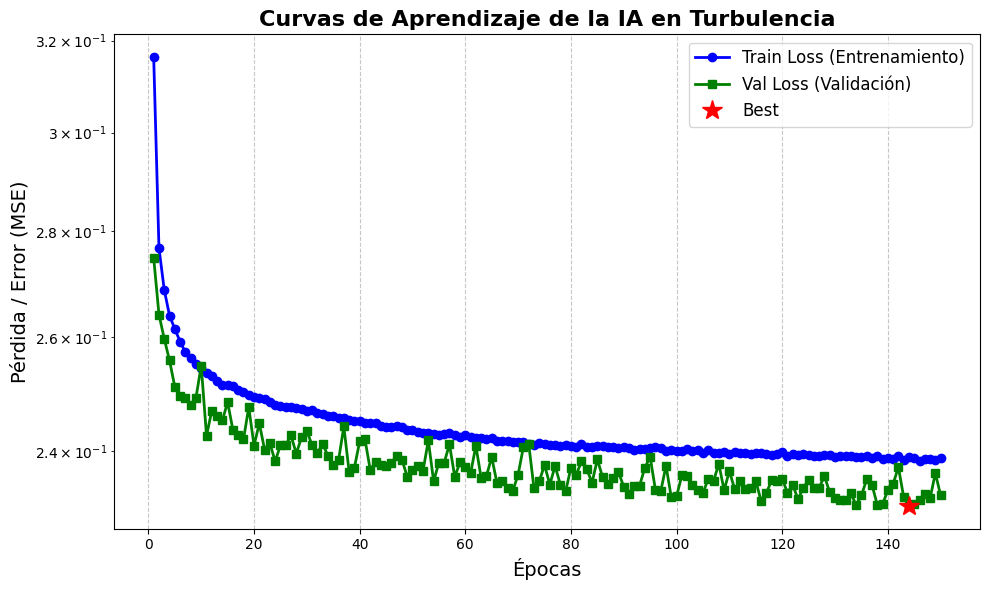

In [ ]:
# 6. VISUALIZACIÓN DE RESULTADOS
import matplotlib.pyplot as plt
import torch # Por si acaso no estaba importado en esta celda
import torch.nn as nn
import numpy as np
import pandas as pd
'''
print("Calculando el Baseline Ingenuo para la gráfica...")

# ==========================================
# 1. CÁLCULO DEL BASELINE (La predicción "estúpida")
# ==========================================
val_loss_ingenua_acumulada = 0.0
criterio_baseline = nn.MSELoss()

with torch.no_grad():
    for x_val, y_val in val_loader:
        x_val = x_val.to(device)
        y_val = y_val.to(device)
        
        # 1. Cogemos el último paso de la ventana de entrada (forma: [64])
        ultimo_valor = x_val[:, -1] 
        
        # 2. Le añadimos una dimensión y lo repetimos 50 veces para igualar al futuro
        # Forma final: [64, 50]
        prediccion_estupida = ultimo_valor.unsqueeze(1).repeat(1, y_val.shape[1])
        
        # 3. Ahora sí podemos comparar 50 predicciones idénticas con 50 realidades
        loss_estupida = criterio_baseline(prediccion_estupida, y_val)
        val_loss_ingenua_acumulada += loss_estupida.item()

baseline_val_loss = val_loss_ingenua_acumulada / len(val_loader)
print(f"🚨 Valor del Baseline (MSE): {baseline_val_loss:.6f}")
'''
# ==========================================
# 2. DIBUJAMOS LA GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))

# Eje X: Número de épocas (de 1 a N)
epocas_x = range(1, len(historial_train_loss) + 1)

#Convertimos en arrays
historial_val_loss_np = np.array(historial_val_loss)
epocas_x_np = np.array(epocas_x)

# Trazamos las curvas de la IA
plt.semilogy(epocas_x, historial_train_loss, 'b-o', label='Train Loss (Entrenamiento)', linewidth=2)
plt.semilogy(epocas_x, historial_val_loss, 'g-s', label='Val Loss (Validación)', linewidth=2)
plt.semilogy(epocas_x[historial_val_loss_np.argmin()], historial_val_loss_np.min(), '*r', label='Best', markersize=15)

# Trazamos la línea infranqueable del baseline
#plt.axhline(y=baseline_val_loss, color='r', linestyle='--', linewidth=2, label='Baseline (Persistencia)')

# Estética y etiquetas
plt.title('Curvas de Aprendizaje de la IA en Turbulencia', fontsize=16, fontweight='bold')
plt.xlabel('Épocas', fontsize=14)
plt.ylabel('Pérdida / Error (MSE)', fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xticks(epocas_x) # Fuerza a que el eje X muestre números enteros

# Ajustamos márgenes y mostramos
plt.tight_layout()
plt.savefig(ruta_carpeta_guardar+'/curvas_aprendizaje.png', dpi=300) # Guardamos la figura en alta resolución
plt.show()


df = pd.DataFrame()
df['epoch']=range(1, len(historial_train_loss)+1)
df['train_loss']=historial_train_loss
df['val_loss']=historial_val_loss
df.to_csv(ruta_carpeta_guardar+'/historial_perdidas.csv', index=False, sep=',', float_format='%.6e')

Entrenando en el dispositivo: cuda
2. Cargando estadísticas y modelo...
3. Extrayendo la nueva línea de fluido (idy=4) del disco...
   -> Datos extraídos en 0.71 segundos.
4. Pasando los datos por la Red Neuronal (Por lotes de 500)...
0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
   -> Predicción IA completada en 0.01 segundos.
5. Desnormalizando y dibujando resultados...


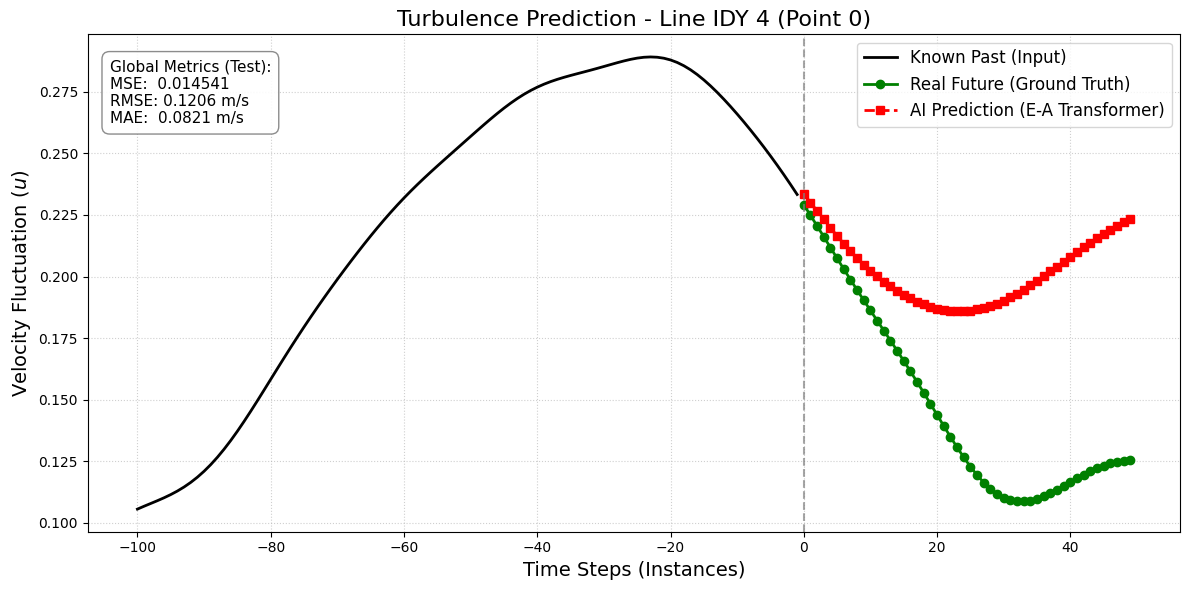

In [9]:
# ==========================================
# FASE DE INFERENCIA: PREDICCIÓN DE TURBULENCIA (VERSIÓN BLINDADA)
# ==========================================
import torch
import h5py
import numpy as np
import time
import matplotlib.pyplot as plt

# Detectar si hay Tarjeta Gráfica (GPU) disponible. Si no, usará la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en el dispositivo: {device}")


# 🚨 AUTODETECCIÓN DE DIMENSIONES 🚨
# train_dataset[0] devuelve la primera tupla (X, Y)
ejemplo_x, ejemplo_y = train_dataset[0]

num_heads = 8  # Puedes ajustar este número según la capacidad de tu GPU y la complejidad que quieras

d_model = 128  # Dimensión interna del modelo (puedes ajustar este número para hacerlo más pequeño o más grande)

input_dim = ejemplo_x.shape[1]  # Cada punto espacial es un canal de entrada

pred_len = ejemplo_y.shape[0]  # Número de pasos futuros a predecir

seq_len = ejemplo_x.shape[0]  # Número de pasos pasados que el modelo usará para predecir

lr=0.0001  # Tasa de aprendizaje para el optimizador



modelo = EasyFluidPredictor(seq_len=seq_len, pred_len=pred_len, input_dim=input_dim, d_model=d_model, num_heads=num_heads)

# --- ⚙️ PARÁMETROS A MODIFICAR ⚙️ ---
ruta_modelo_campeon = ruta_carpeta_guardar + '/mejor_modelo_ia_transformer_eas.pt' 
ruta_stats = 'norm_stats_tf_pro1.pt'
linea_idy_test = 4  # ¡LA NUEVA LÍNEA!

# ==========================================
# 1. CARGAR EL MODELO Y LAS ESTADÍSTICAS
# ==========================================
print("2. Cargando estadísticas y modelo...")
stats = torch.load(ruta_stats, weights_only=False)
media_X = stats['media']
std_X = stats['std']

checkpoint_completo = torch.load(ruta_modelo_campeon, weights_only=False)
modelo.load_state_dict(checkpoint_completo['model_state_dict'])
modelo.to(device)
modelo.eval() # 🔴 MODO EXAMEN: APAGAR ENTRENAMIENTO

# ==========================================
# 2. PREPARAR LOS DATOS DE LA NUEVA LÍNEA
# ==========================================
print(f"3. Extrayendo la nueva línea de fluido (idy={linea_idy_test}) del disco...")
inicio = time.time()
with h5py.File(ruta_maestra, 'r') as f:
    matriz_base = f['data_analisis']['u_fluc'][:, linea_idy_test, :] 
    chunk_size = 5050
    num_chunks = len(matriz_base) // chunk_size 
    matriz_recortada = matriz_base[:num_chunks * chunk_size, :]
    
    trozos = []
    for i in range(num_chunks):
        trozos.append(matriz_recortada[i*chunk_size:(i+1)*chunk_size, :])
    matriz_final_test = np.hstack(trozos) 
print(f"   -> Datos extraídos en {time.time() - inicio:.2f} segundos.")

X_test_raw = matriz_final_test[5000-seq_len:5000, :] 
y_test_real = matriz_final_test[5000:5000+pred_len, :]  

X_test_norm = (X_test_raw - media_X) / std_X
X_tensor = torch.tensor(X_test_norm.T, dtype=torch.float32).unsqueeze(-1).to(device)

# ==========================================
# 3. LA PREDICCIÓN (CON PROTECCIÓN DE GPU)
# ==========================================
print("4. Pasando los datos por la Red Neuronal (Por lotes de 500)...")
inicio = time.time()
tamano_lote = 500  
predicciones = []

with torch.no_grad(): 
    for i in range(0, X_tensor.shape[0], tamano_lote):
        print(i)
        X_batch = X_tensor[i : i + tamano_lote]
        y_batch = modelo(X_batch)
        predicciones.append(y_batch)

y_pred_norm = torch.cat(predicciones, dim=0) 
print(f"   -> Predicción IA completada en {time.time() - inicio:.2f} segundos.")

# --- 🧹 LIMPIEZA DE MEMORIA VITAL ---
del X_tensor
del predicciones
torch.cuda.empty_cache()

# ==========================================
# 4. DESNORMALIZAR Y PREPARAR GRÁFICA
# ==========================================
print("5. Desnormalizando y dibujando resultados...")
y_pred_numpy = y_pred_norm.squeeze(-1).cpu().numpy()
y_pred_real = (y_pred_numpy * std_X) + media_X
y_pred_real = y_pred_real.T 

mse_test = np.mean((y_test_real - y_pred_real)**2)
rmse_test = np.sqrt(mse_test)
mae_test = np.mean(np.abs(y_test_real - y_pred_real))

punto_espacial = 0 

plt.figure(figsize=(12, 6))
pasado_reciente = X_test_raw[-100:, punto_espacial]
tiempo_pasado = range(-100, 0)
plt.plot(tiempo_pasado, pasado_reciente, 'k-', label='Known Past (Input)', linewidth=2)

tiempo_futuro = range(0, 50)
plt.plot(tiempo_futuro, y_test_real[:, punto_espacial], 'g-o', label='Real Future (Ground Truth)', linewidth=2)
plt.plot(tiempo_futuro, y_pred_real[:, punto_espacial], 'r--s', label='AI Prediction (E-A Transformer)', linewidth=2)

texto_metricas = (
    f"Global Metrics (Test):\n"
    f"MSE:  {mse_test:.6f}\n"
    f"RMSE: {rmse_test:.4f} m/s\n"
    f"MAE:  {mae_test:.4f} m/s"
)

plt.gca().text(0.02, 0.95, texto_metricas, 
               transform=plt.gca().transAxes, 
               fontsize=11, 
               verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title(f'Turbulence Prediction - Line IDY {linea_idy_test} (Point {punto_espacial})', fontsize=16)
plt.xlabel('Time Steps (Instances)', fontsize=14)
plt.ylabel('Velocity Fluctuation ($u$)', fontsize=14)
plt.legend(loc='upper right', fontsize=12) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

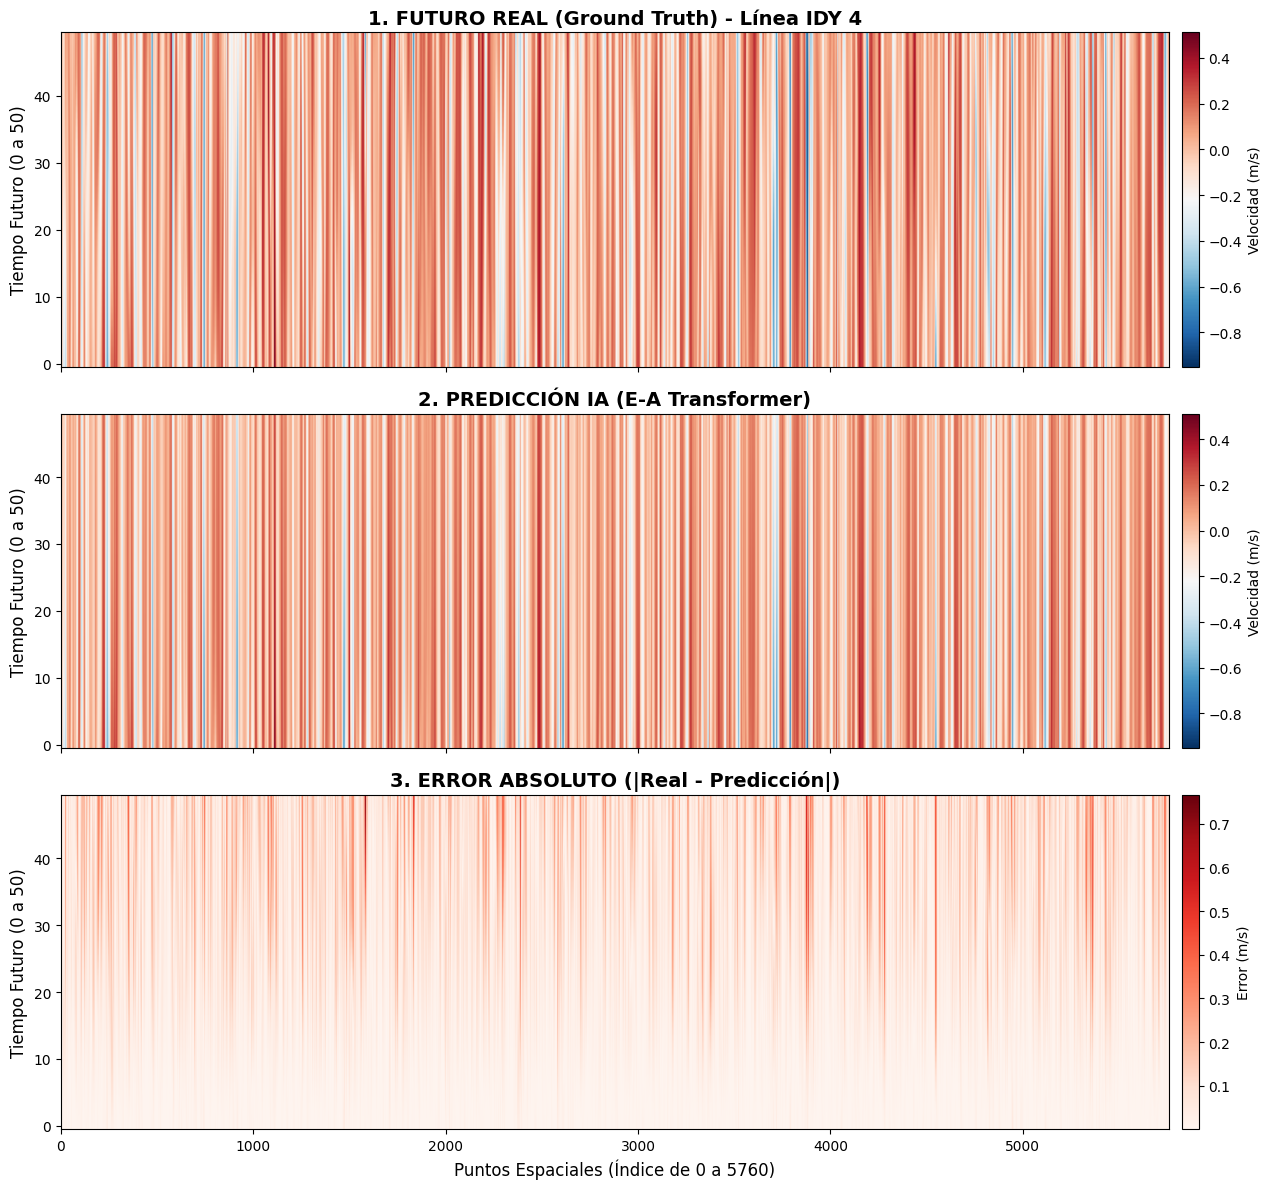

In [ ]:
# ==========================================
# VISUALIZACIÓN CFD: MAPA DE CALOR ESPACIO-TEMPORAL
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Creamos una figura grande con 3 paneles apilados
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)

# 2. Fijamos los límites de color para que los 3 gráficos usen la misma escala
# Usamos el máximo y mínimo de la realidad para comparar justamente
vmin_val = np.min(y_test_real)
vmax_val = np.max(y_test_real)

# --- PANEL 1: FUTURO REAL (Lo que hizo el fluido de verdad) ---
im1 = ax1.imshow(y_test_real, aspect='auto', cmap='RdBu_r', origin='lower', 
                 vmin=vmin_val, vmax=vmax_val)
ax1.set_title(f"1. FUTURO REAL (Ground Truth) - Línea IDY {linea_idy_test}", fontsize=14, fontweight='bold')
ax1.set_ylabel("Tiempo Futuro (0 a 50)", fontsize=12)
fig.colorbar(im1, ax=ax1, pad=0.01, label="Velocidad (m/s)")

# --- PANEL 2: PREDICCIÓN IA (Lo que cree tu modelo LSTM) ---
im2 = ax2.imshow(y_pred_real, aspect='auto', cmap='RdBu_r', origin='lower', 
                 vmin=vmin_val, vmax=vmax_val)
ax2.set_title("2. PREDICCIÓN IA (E-A Transformer)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Tiempo Futuro (0 a 50)", fontsize=12)
fig.colorbar(im2, ax=ax2, pad=0.01, label="Velocidad (m/s)")

# --- PANEL 3: ERROR ABSOLUTO (Dónde falla el modelo) ---
error_absoluto = np.abs(y_test_real - y_pred_real)
im3 = ax3.imshow(error_absoluto, aspect='auto', cmap='Reds', origin='lower')
ax3.set_title("3. ERROR ABSOLUTO (|Real - Predicción|)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Puntos Espaciales (Índice de 0 a 5760)", fontsize=12)
ax3.set_ylabel("Tiempo Futuro (0 a 50)", fontsize=12)
fig.colorbar(im3, ax=ax3, pad=0.01, label="Error (m/s)")

# Ajustamos el layout y mostramos
plt.tight_layout()
plt.show()

Generando 50 pasos autoregresivos desde el instante 5030...


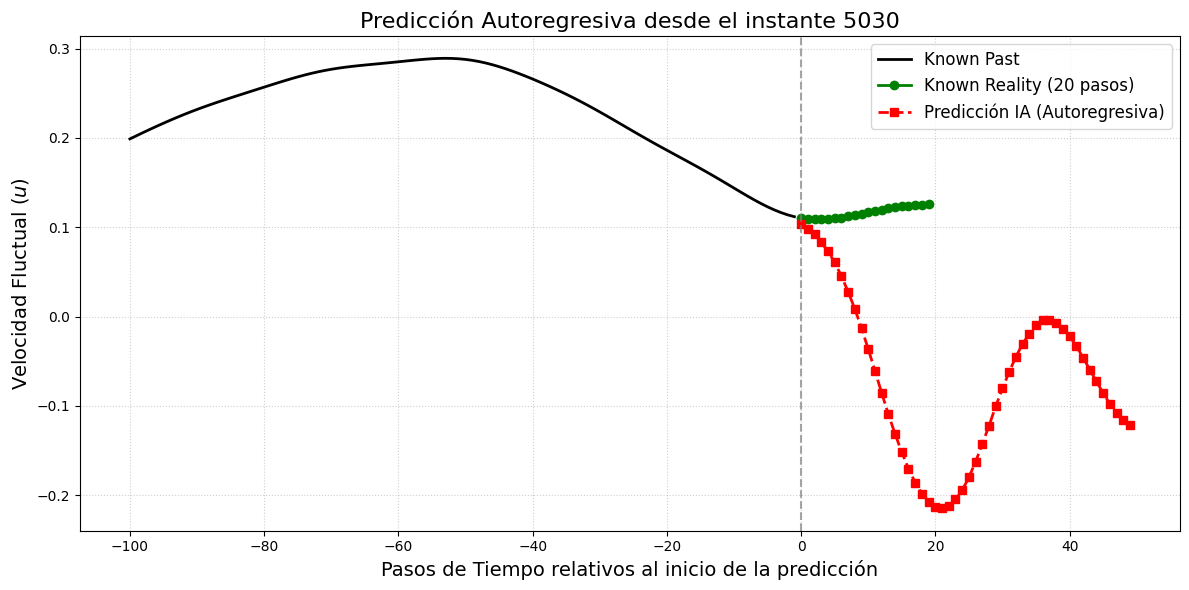

In [10]:
# ==========================================
# 🔮 INFERENCIA AUTOREGRESIVA (PASO A PASO)
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt

instante_objetivo = 5030
punto_espacial = 0 
saltos=1

print(f"Generando 50 pasos autoregresivos desde el instante {instante_objetivo}...")

# 1. Historia inicial y realidad futura (Igual que antes)
pasado_raw = matriz_final_test[instante_objetivo - seq_len : instante_objetivo, punto_espacial]
futuro_real_raw = matriz_final_test[instante_objetivo : instante_objetivo + pred_len, punto_espacial]
pasos_reales_disponibles = len(futuro_real_raw)

pasado_norm = (pasado_raw - stats_norm['media']) / stats_norm['std']
historia_actual = torch.tensor(pasado_norm, dtype=torch.float32).view(1, seq_len, 1).to(device)

predicciones_paso_a_paso = []
modelo.eval()

# 2. EL BUCLE AUTOREGRESIVO (La Magia)
with torch.no_grad():
    for _ in range(0,pred_len,saltos): # Lo hacemos 50 veces
        # Predecimos
        pred_completa = modelo(historia_actual)
        
        # Nos quedamos SOLO con el primer instante futuro (el más preciso)
        siguiente_paso = pred_completa[:, 0:1, :] 
        predicciones_paso_a_paso.append(siguiente_paso.cpu().numpy().squeeze())
        
        # Desplazamos la ventana: quitamos el más viejo y metemos el nuevo
        historia_actual = torch.cat((historia_actual[:, 1:, :], siguiente_paso), dim=1)

# Desnormalizamos las 50 predicciones paso a paso
predicciones_numpy = np.array(predicciones_paso_a_paso)
prediccion_real = (predicciones_numpy * stats_norm['std']) + stats_norm['media']

# ==========================================
# 📊 DIBUJAMOS LA COMPARATIVA
# ==========================================
plt.figure(figsize=(12, 6))

tiempo_pasado = range(-seq_len, 0)
tiempo_futuro_ia = range(0, pred_len,saltos)                   
tiempo_futuro_real = range(0, pasos_reales_disponibles) 

plt.plot(tiempo_pasado[-100:], pasado_raw[-100:], 'k-', label='Known Past', linewidth=2)

if pasos_reales_disponibles > 0:
    plt.plot(tiempo_futuro_real, futuro_real_raw, 'g-o', label=f'Known Reality ({pasos_reales_disponibles} pasos)', linewidth=2)

# Dibujamos nuestra nueva curva construida pasito a pasito
plt.plot(tiempo_futuro_ia, prediccion_real, 'r--s', label=f'Predicción IA (Autoregresiva)', linewidth=2)

plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title(f'Predicción Autoregresiva desde el instante {instante_objetivo}', fontsize=16)
plt.xlabel('Pasos de Tiempo relativos al inicio de la predicción', fontsize=14)
plt.ylabel('Velocidad Fluctual ($u$)', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Prediciendo con E-A Transformer 50 pasos desde el instante 5010...


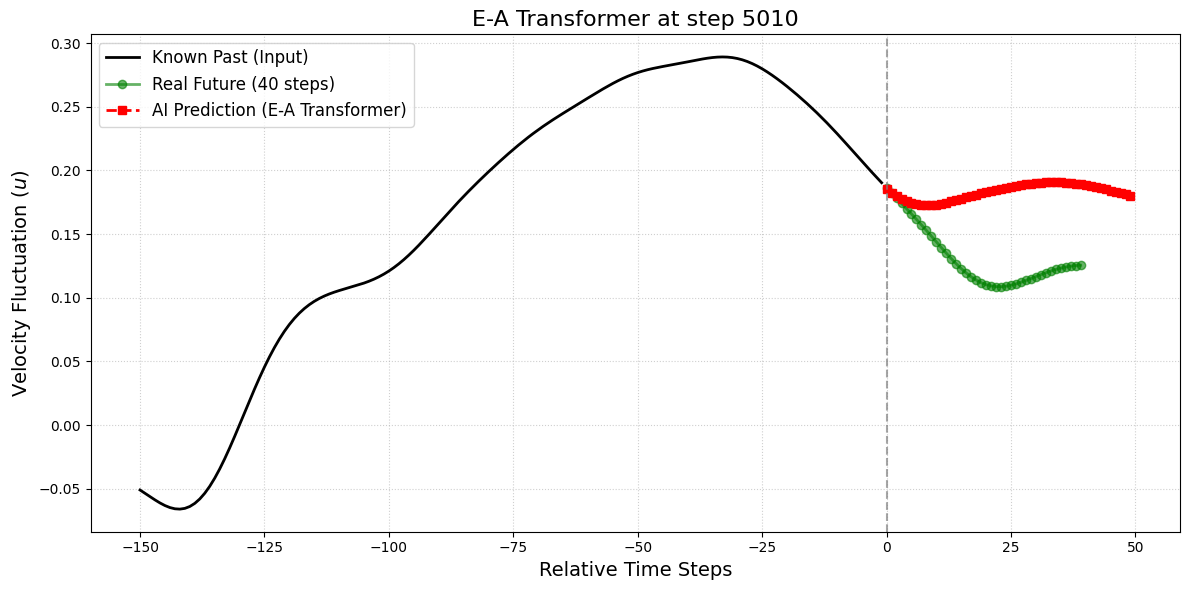

In [12]:
# ==========================================
# 🔮 PREDICCIÓN EXTREMA TRANSFORMER (EL SALTO AL FUTURO)
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- ⚙️ PARÁMETROS ADAPTADOS ---
# Asegúrate de que estos coincidan con tu mejor Run del Transformer (ej. Run 5)
instante_objetivo = 5010  
punto_espacial = 0 
seq_len = 3000             # 🚨 Ajusta esto (300, 500 o 1500) según tu entrenamiento
pred_len = 50             
# ---------------------

print(f"Prediciendo con E-A Transformer {pred_len} pasos desde el instante {instante_objetivo}...")

# 1. Extraer la historia (300 pasos antes del objetivo)
pasado_raw = matriz_final_test[instante_objetivo - seq_len : instante_objetivo, punto_espacial]

# 2. Extraer la realidad disponible para comparar
limite_real = min(instante_objetivo + pred_len, matriz_final_test.shape[0])
futuro_real_raw = matriz_final_test[instante_objetivo : limite_real, punto_espacial]
pasos_reales_disponibles = len(futuro_real_raw)

# 3. Normalización y preparación del Tensor 3D
# Usamos las estadísticas que guardaste en stats_norm
pasado_norm = (pasado_raw - stats_norm['media']) / stats_norm['std']

# 🚨 IMPORTANTE: El Transformer espera [Batch, Seq_len, Channels] -> (1, 300, 1)
x_tensor = torch.tensor(pasado_norm, dtype=torch.float32).view(1, seq_len, 1).to(device)

# 4. Inferencia del modelo mejorado
modelo.eval()
with torch.no_grad():
    # El modelo devuelve [1, 50, 1]
    prediccion_norm = modelo(x_tensor)

# 5. Desnormalización
prediccion_numpy = prediccion_norm.cpu().numpy().squeeze() # Quitamos dimensiones de 1 -> (50,)
prediccion_real = (prediccion_numpy * stats_norm['std']) + stats_norm['media']

# ==========================================
# 📊 DIBUJAMOS LA COMPARATIVA
# ==========================================
plt.figure(figsize=(12, 6))

# Ejes de tiempo relativos
tiempo_pasado = range(-seq_len, 0)
tiempo_futuro_ia = range(0, pred_len)
tiempo_futuro_real = range(0, pasos_reales_disponibles)

# Dibujamos el pasado conocido (Zoom a los últimos 150 para ver el empalme)
plt.plot(tiempo_pasado[-150:], pasado_raw[-150:], 'k-', label='Known Past (Input)', linewidth=2)

# Dibujamos la realidad (Ground Truth)
if pasos_reales_disponibles > 0:
    plt.plot(tiempo_futuro_real, futuro_real_raw, 'g-o', label=f'Real Future ({pasos_reales_disponibles} steps)', linewidth=2, alpha=0.6)

# Dibujamos la predicción del Transformer
plt.plot(tiempo_futuro_ia, prediccion_real, 'r--s', label=f'AI Prediction (E-A Transformer)', linewidth=2)

plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.title(f'E-A Transformer at step {instante_objetivo}', fontsize=16)
plt.xlabel('Relative Time Steps', fontsize=14)
plt.ylabel('Velocity Fluctuation ($u$)', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

5. Desnormalizando, calculando error espacial y dibujando resultados...


<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_23161/1447802379.py:50: SyntaxWarning: invalid escape sequence '\p'
  label='Dispersión Espacial ($\pm1$ Std Dev)')


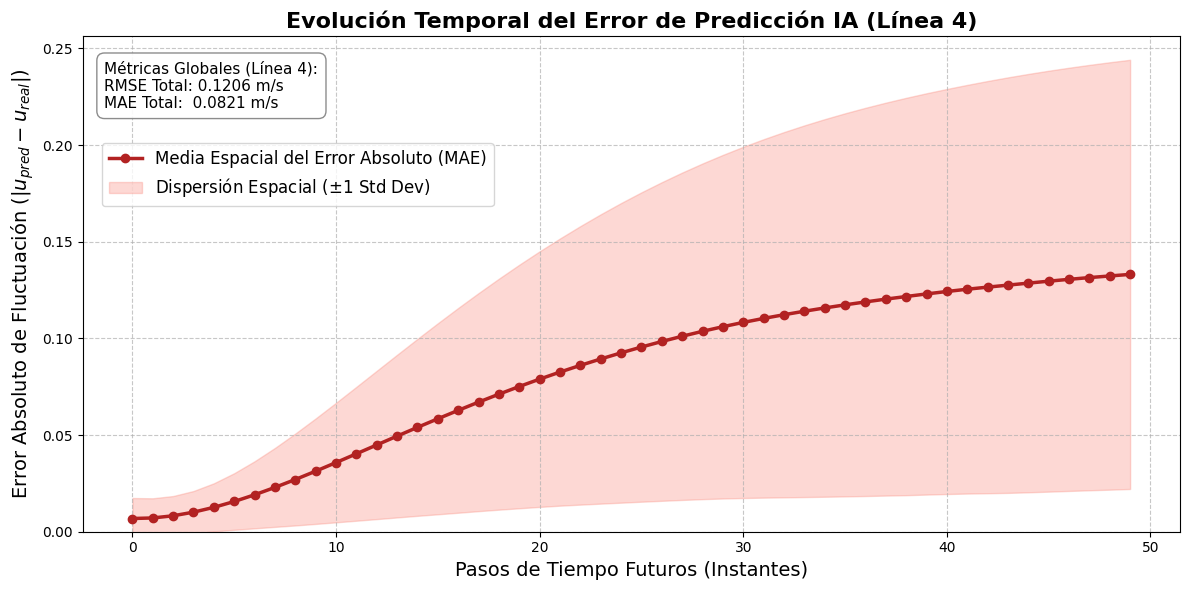

In [14]:
#Medias y desviaciones estándar de los errores absolutos

# ==========================================
# 4. CÁLCULO DEL ERROR ESPACIAL Y GRÁFICA
# ==========================================
print("5. Desnormalizando, calculando error espacial y dibujando resultados...")
y_pred_numpy = y_pred_norm.squeeze(-1).cpu().numpy()

# 1. Deshacemos la normalización (Z-Score)
# Recordatorio: y_pred_numpy tiene forma (5760, 50). Hay que transponerlo a (50, 5760)
y_pred_real = (y_pred_numpy * std_X) + media_X
y_pred_real = y_pred_real.T # Ahora tiene forma (tiempo_futuro, espacio) = (50, 5760)

# y_test_real ya tiene la forma (50, 5760)

# ==============================================================
# 2. CÁLCULO DE LA EVOLUCIÓN TEMPORAL DEL ERROR (TU PETICIÓN)
# ==============================================================

# Calculamos el error absoluto punto por punto
# matriz de error tendrá forma (50, 5760)
error_absoluto_matriz = np.abs(y_test_real - y_pred_real)

# Colapsamos el eje 1 (el espacio, las 5760 columnas) para obtener 
# la media y la desviación estándar para CADA instante de tiempo (eje 0)
error_medio_temporal = np.mean(error_absoluto_matriz, axis=1) # Forma (50,)
std_error_temporal = np.std(error_absoluto_matriz, axis=1)    # Forma (50,)

# ==============================================================
# 3. CREACIÓN DE LA GRÁFICA
# ==============================================================

plt.figure(figsize=(12, 6))
tiempo_futuro = range(0, pred_len) # Normalmente de 0 a 50

# 1. Dibujamos la línea de la Media del Error
plt.plot(tiempo_futuro, error_medio_temporal, 
         color='firebrick', 
         linestyle='-', 
         marker='o',
         linewidth=2.5, 
         label='Media Espacial del Error Absoluto (MAE)')

# 2. Dibujamos la franja de dispersión (Media ± 1 Desviación Estándar)
plt.fill_between(tiempo_futuro, 
                 error_medio_temporal - std_error_temporal, 
                 error_medio_temporal + std_error_temporal, 
                 color='salmon', 
                 alpha=0.3, 
                 label='Dispersión Espacial ($\pm1$ Std Dev)')

# --- TEXTO DE MÉTRICAS GLOBALES (Opcional, pero útil) ---
mse_global = np.mean((y_test_real - y_pred_real)**2)
rmse_global = np.sqrt(mse_global)
mae_global = np.mean(error_absoluto_matriz)

texto_metricas = (
    f"Métricas Globales (Línea {linea_idy_test}):\n"
    f"RMSE Total: {rmse_global:.4f} m/s\n"
    f"MAE Total:  {mae_global:.4f} m/s"
)

plt.gca().text(0.02, 0.95, texto_metricas, 
               transform=plt.gca().transAxes, 
               fontsize=11, 
               verticalalignment='top',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

# --- CONFIGURACIÓN VISUAL ---
plt.title(f'Evolución Temporal del Error de Predicción IA (Línea {linea_idy_test})', fontsize=16, fontweight='bold')
plt.xlabel('Pasos de Tiempo Futuros (Instantes)', fontsize=14)
plt.ylabel('Error Absoluto de Fluctuación ($|u_{pred} - u_{real}|$)', fontsize=14)

# Aseguramos que el eje Y empiece en 0, ya que el error absoluto no puede ser negativo
plt.ylim(bottom=0) 

plt.legend(loc='upper left', fontsize=12, bbox_to_anchor=(0.01, 0.8)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()